## **Replicação de Artigos**

In [1]:
# Importando Bibliotecas
import os
import pandas as pd
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Importando Modelos
from src.models.unet.unet import UNet
from src.models.unet.unet_pretrained import UNet_ImageNet
from src.models.artigo_full_hrnet.full_hrnet import FullHRNet
from src.models.artigo_full_hrnet.full_hrnet_pretrained import FullHRNet_ImageNet

# Importar sua classe existente
from src.vfss_dataset import VFSSImageDataset

from src.split_data import split_data_k_fold
from src.utils import (plot_image_with_mask,
                       get_script_relative_path,
                       get_project_root_directory,
                       get_corners_from_angle,
                       clahe,
                       modify_input,
                       load_points,
                       custom_collate_fn,
                       set_seed,
                       avalia_status_GPU,
                       resolve_dataframe_path)

# Importando classes/funções - Podar imports que não são chamados aqui.
from src.training.config import TrainingConfig
from src.training.loss import (LossCalculator,
                               FocalMSELoss,
                               FocalMSEMaskedLoss)
from src.training.holdout import holdout
from src.training.cross_validation import cross_validate
from src.evalutation.inference import evaluate_model_on_test

set_seed(42)

## **Full HR-Net**

### **Configuração**

In [5]:
# Parametros Básicos Iniciais
epochs = 200
width = 48

model_class = FullHRNet_ImageNet
criterion_heatmap = nn.MSELoss()
criterion_roi = nn.BCEWithLogitsLoss()

model_name = f"{model_class.__name__}\\{criterion_heatmap.__class__.__name__}_{str(epochs)}ep_{str(width)}W"
print("="*30, f"\n{model_name}\n", "="*30)

model_kwargs = {
    "num_keypoints": 2,
    "width": width,
    "pretrained_path": f"model_weights/FullHRNet_ImageNet/model_hrnet_w{width}_imagenet.pth"
}

# Caminhos Importantes
videos_dir = 'data\\videos\\' 
labels_dir = 'data\\rotulos\\anotacoes-tecgraf\\'
frames_dir = 'data\\frames'
augmentation_dir = 'data/frames_augmentation'
path_dataframe = "data/metadados/video_frame_metadata.csv"

root = get_project_root_directory()
path_dataframe = os.path.join(root, path_dataframe)
video_frame_df = pd.read_csv(path_dataframe)
video_frame_df = video_frame_df.apply(resolve_dataframe_path, axis = 1)

# Adicionando os pontos direto no dataframe, para não precisar ficar abrindo arquivos
video_frame_df["keypoints"] = video_frame_df["target_dir"].apply(load_points)

# Atributos da função VFSSImageDataset
sigma_heatmap = 20
output_dim = (448, 448)
offline_augmentation = True

transform_augmentation_online = A.Compose([
        A.PixelDropout(dropout_prob = 0.01, p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
        A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
        A.CropAndPad(px=(-30, 30), p=0.5),
        A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
        A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
        A.GaussNoise(var_limit=(00.0, 10.0), mean=0, p=0.5),   # Ruído Gaussiano
        A.Resize(output_dim[0], output_dim[1]),
        ToTensorV2()
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_augmentation_offline = A.Compose([
        A.PixelDropout(dropout_prob = 0.01, p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
        A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
        A.CropAndPad(px=(-30, 30), p=0.5),
        A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
        
        A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
        A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano
        A.Resize(output_dim[0], output_dim[1])
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_puro = A.Compose([A.Resize(output_dim[0], output_dim[1]),
                       ToTensorV2()],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Configuração
config = TrainingConfig(
         model_class    = model_class,
         model_kwargs   = model_kwargs,
         dataset_class  = VFSSImageDataset,
         sigma_heatmap  = sigma_heatmap,
         
         # Hiperparâmetros do Modelo 
         learning_rate  = 0.001,
         batch_size     = 8,
         epochs         = epochs,
         patience       = 5,
         lr_patience    = 1e-10,
         scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau,
         
         # Funções e Transformações
         output_dim           = output_dim,
         modify_input_fn      = None, # modify_input,
         collate_fn           = custom_collate_fn,
         transform_train      = transform_puro,
         transform_validation = transform_puro,
 
         # Função de Loss
         criterion_roi       = criterion_roi,       
         criterion_heatmap   = criterion_heatmap,   
         weight_roi          = 0.0,
         weight_heatmap      = 0.5,
         weight_penalty      = 0.0,
         
         # Offline Augmentation
         offline_augmentation    = offline_augmentation,
         transform_augmentation  = transform_augmentation_offline,
         augmentation_dir        = augmentation_dir,
         n_aug                   = 5,
 
         # Outros
         checkpoint_dir  = f"data\\model_weights\\{model_name}",
         device          = "cuda" if torch.cuda.is_available() else "cpu",
         )


# Aplicando a divisão dos Folds
print("\nSplit Dados")
list_df_folds, df_test = split_data_k_fold(video_frame_df, test_size=0.2, n_folds=5)

# Avaliando Status do Uso da GPU
avalia_status_GPU()

FullHRNet_ImageNet\MSELoss_200ep_48W

Split Dados
Folds all: 92
Test: 23
Overall Dataset - Videos: 234 | Patients: 115 | Frames: 973 (100.0%)
Training + Validation Set - Videos: 192 | Patients: 92 | Frames: 795 (81.7%)
Test Set - Videos: 42 | Patients: 23 | Frames: 178 (18.3%)

Fold 1 - Videos: 41 | Patients: 19 | Frames: 174 (17.9%)
Fold 2 - Videos: 56 | Patients: 19 | Frames: 230 (23.6%)
Fold 3 - Videos: 40 | Patients: 18 | Frames: 168 (17.3%)
Fold 4 - Videos: 26 | Patients: 18 | Frames: 108 (11.1%)
Fold 5 - Videos: 29 | Patients: 18 | Frames: 115 (11.8%)


,split_name,n_videos,n_patients,n_frames,percentage_of_initial_frames,video_ids
0,fold_1,41,19,174,0.178828,"[101, 102, 103, 104, 105, 106, 107, 108, 109, ..."
1,fold_2,56,19,230,0.236382,"[129, 130, 131, 132, 136, 137, 138, 139, 140, ..."
2,fold_3,40,18,168,0.172662,"[122, 123, 125, 126, 127, 128, 152, 153, 154, ..."
3,fold_4,26,18,108,0.110997,"[10, 113, 114, 115, 116, 117, 118, 119, 120, 1..."
4,fold_5,29,18,115,0.118191,"[192, 193, 194, 195, 196, 197, 198, 199, 200, ..."
5,test_set,42,23,178,0.182939,"[100, 11, 13, 142, 143, 144, 145, 146, 147, 14..."



VERIFICAÇÃO DE GPU
PyTorch version: 2.2.2+cu121
CUDA disponível: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 2080 Ti
Número de GPUs: 1



### **Treino/Validação**

In [6]:
# TREINO

# Holdout Training sem tunagem

results = holdout(
    df_train=pd.concat([list_df_folds[j] for j in range(1,5)], ignore_index=True),
    df_val=list_df_folds[0],
    config=config,
)

Arquivos antigos de augmentation apagados!


Offline Augmentation - Processando em Paralelo: 100%|██████████| 621/621 [00:28<00:00, 21.41it/s]


Arquivo de pesos não encontrado em: model_weights/FullHRNet_ImageNet/model_hrnet_w48_imagenet.pth


Treinando: 100%|██████████| 389/389 [00:51<00:00,  7.52it/s]


Época 1/200
  Train Loss: 0.0518 | Val Loss: 0.0040
  Val Components - ROI: 0.0000, Heatmap: 0.0080, Penalty: 0.0132
✓ Melhor modelo salvo (val_loss: 0.0040)


...

Época 18/200
  Train Loss: 0.0003 | Val Loss: 0.0006
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0025


Treinando: 100%|██████████| 389/389 [00:21<00:00, 17.75it/s]


Época 19/200
  Train Loss: 0.0003 | Val Loss: 0.0006
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0027


Treinando: 100%|██████████| 389/389 [00:21<00:00, 17.75it/s]


Época 20/200
  Train Loss: 0.0003 | Val Loss: 0.0006
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0028
Early stopping ativado na época 20
✓ Checkpoint carregado: epoch 14, val_loss: 0.0006

Loss Final: 0.0006

RESULTADOS FINAIS
Média dos Folds: 0.0006 ± 0.0000
Melhor Fold: 1 (Loss: 0.0006)


### **Teste**


INICIANDO AVALIAÇÃO NO CONJUNTO DE TESTE
Arquivo de pesos não encontrado em: model_weights/FullHRNet_ImageNet/model_hrnet_w48_imagenet.pth
✓ Modelo carregado: data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_48W\fold_1_best.pth
  Epoch: 14
  Val Loss: 0.0006

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:04<00:00, 39.90it/s]



GERANDO VISUALIZAÇÕES
✓ Gráfico salvo: figs\FullHRNet_ImageNet\MSELoss_200ep_48W\fold1\loss_distributions.png


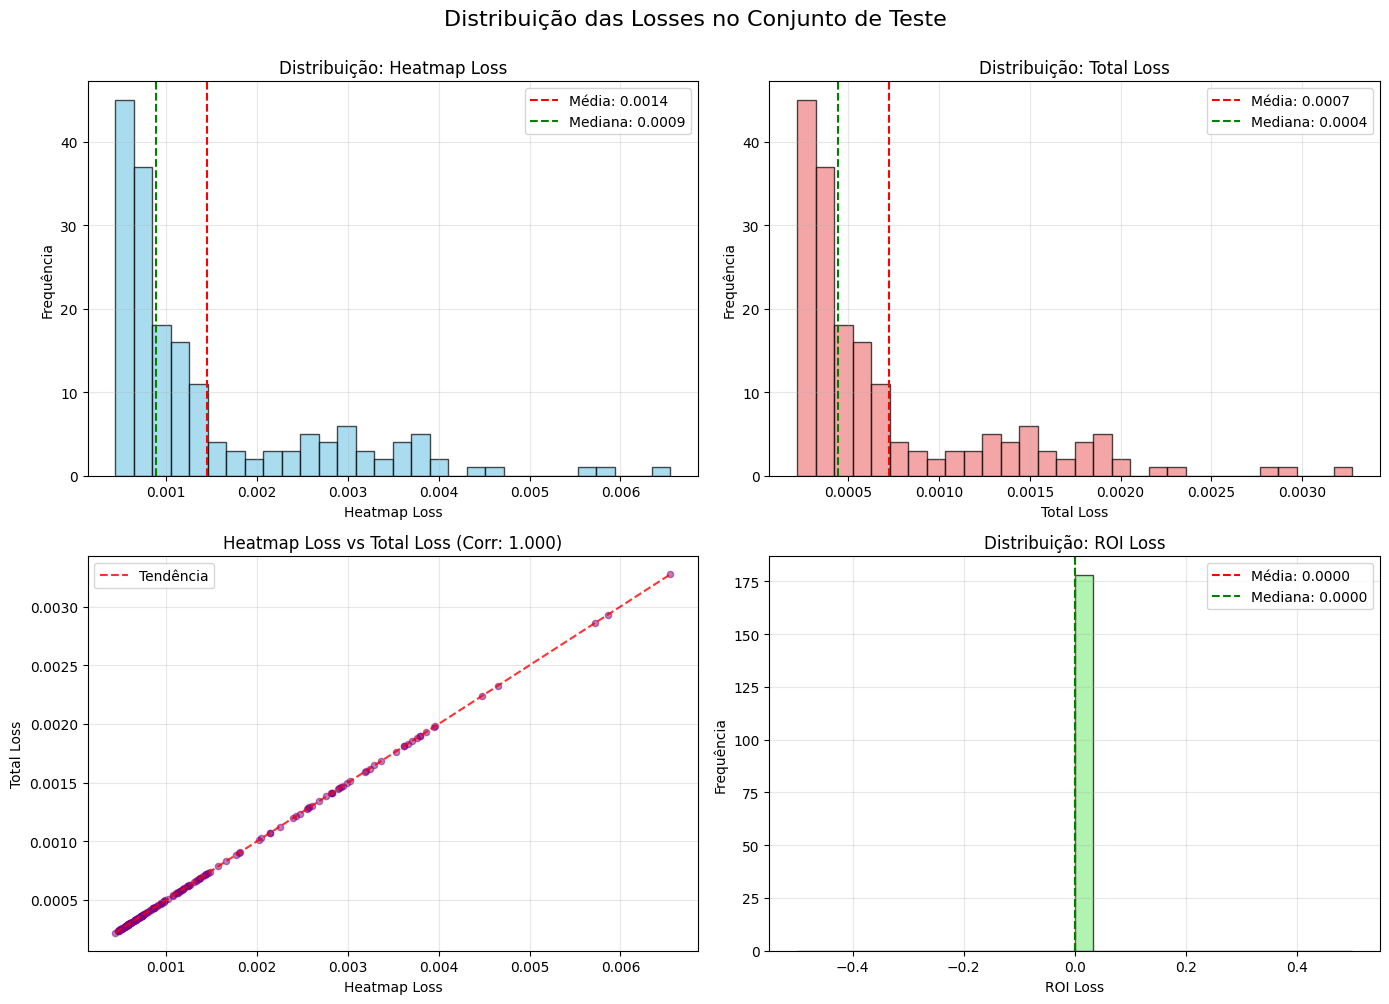

✓ Gráfico salvo: figs\FullHRNet_ImageNet\MSELoss_200ep_48W\fold1\keypoint_analysis.png


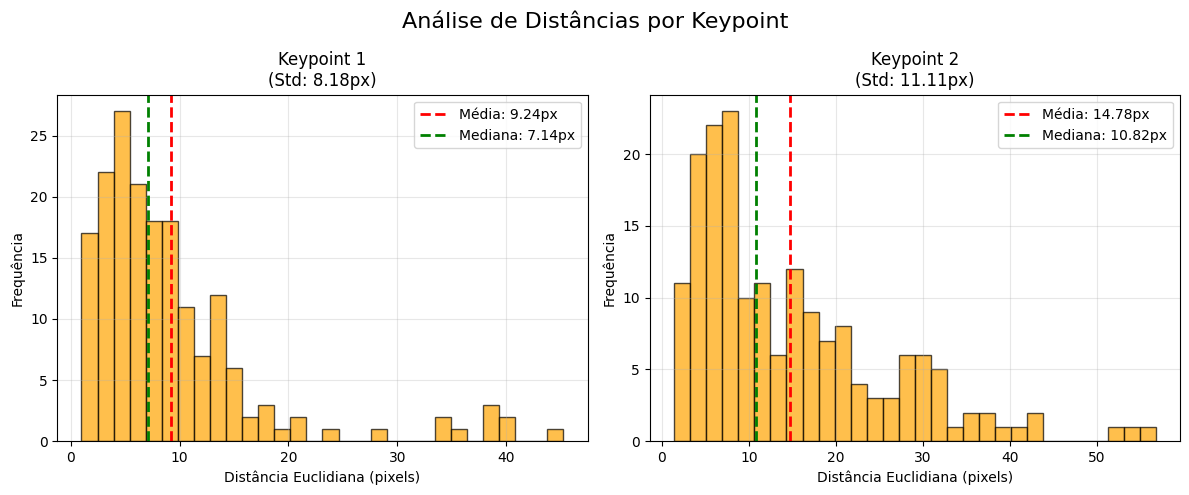


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_48W\fold1\predictions_by_distance_keypoint1.png


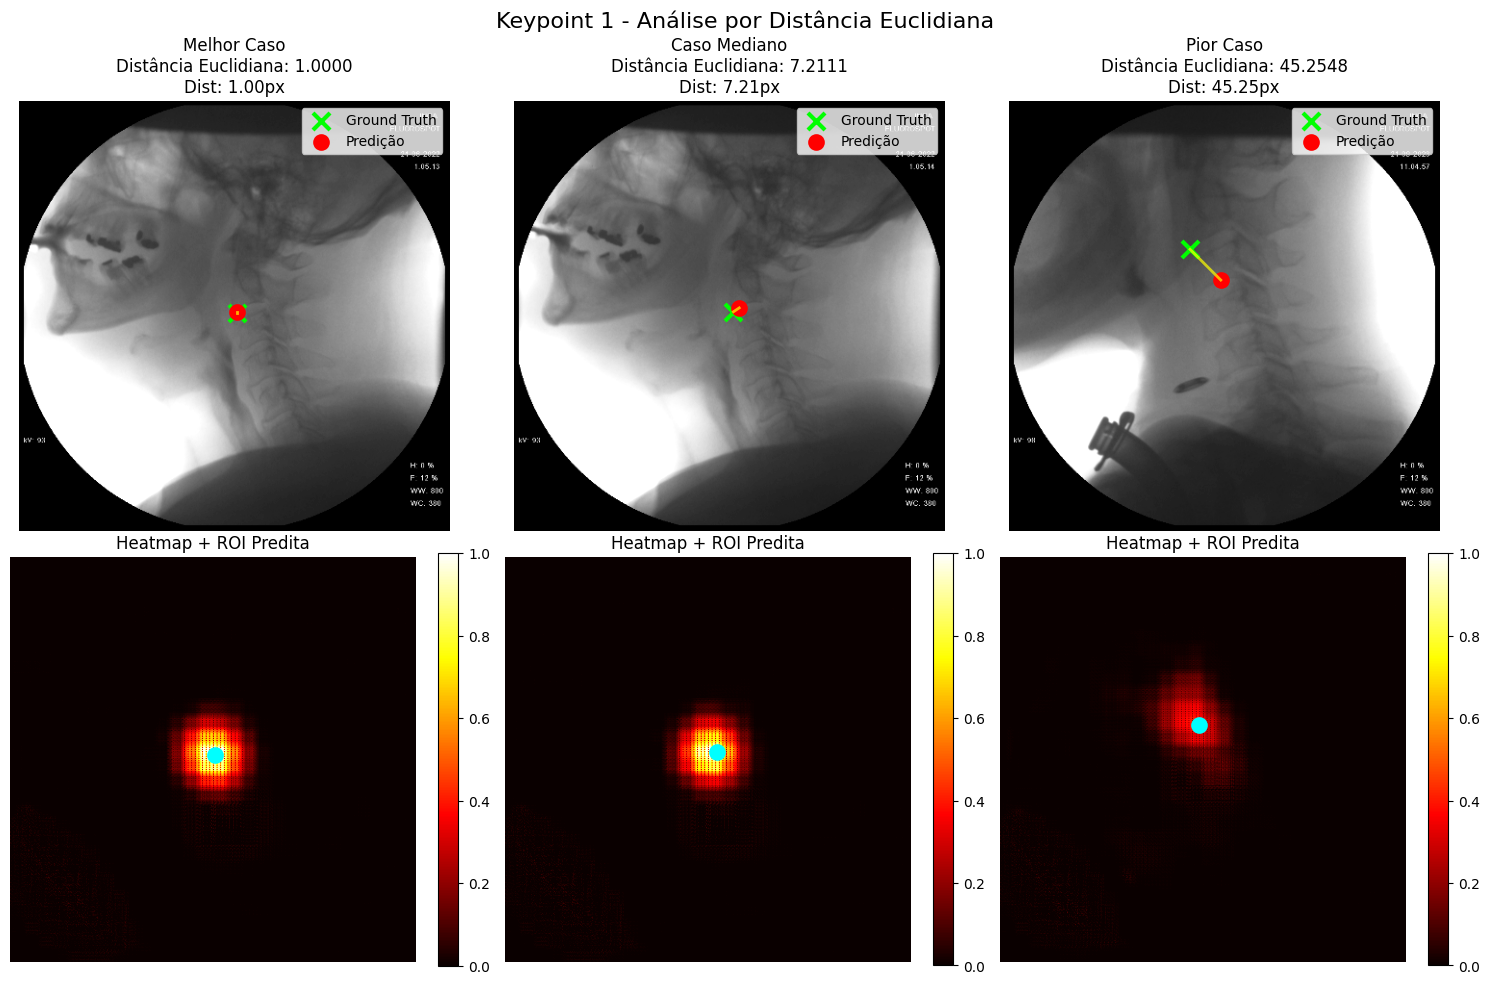


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_48W\fold1\predictions_by_distance_keypoint2.png


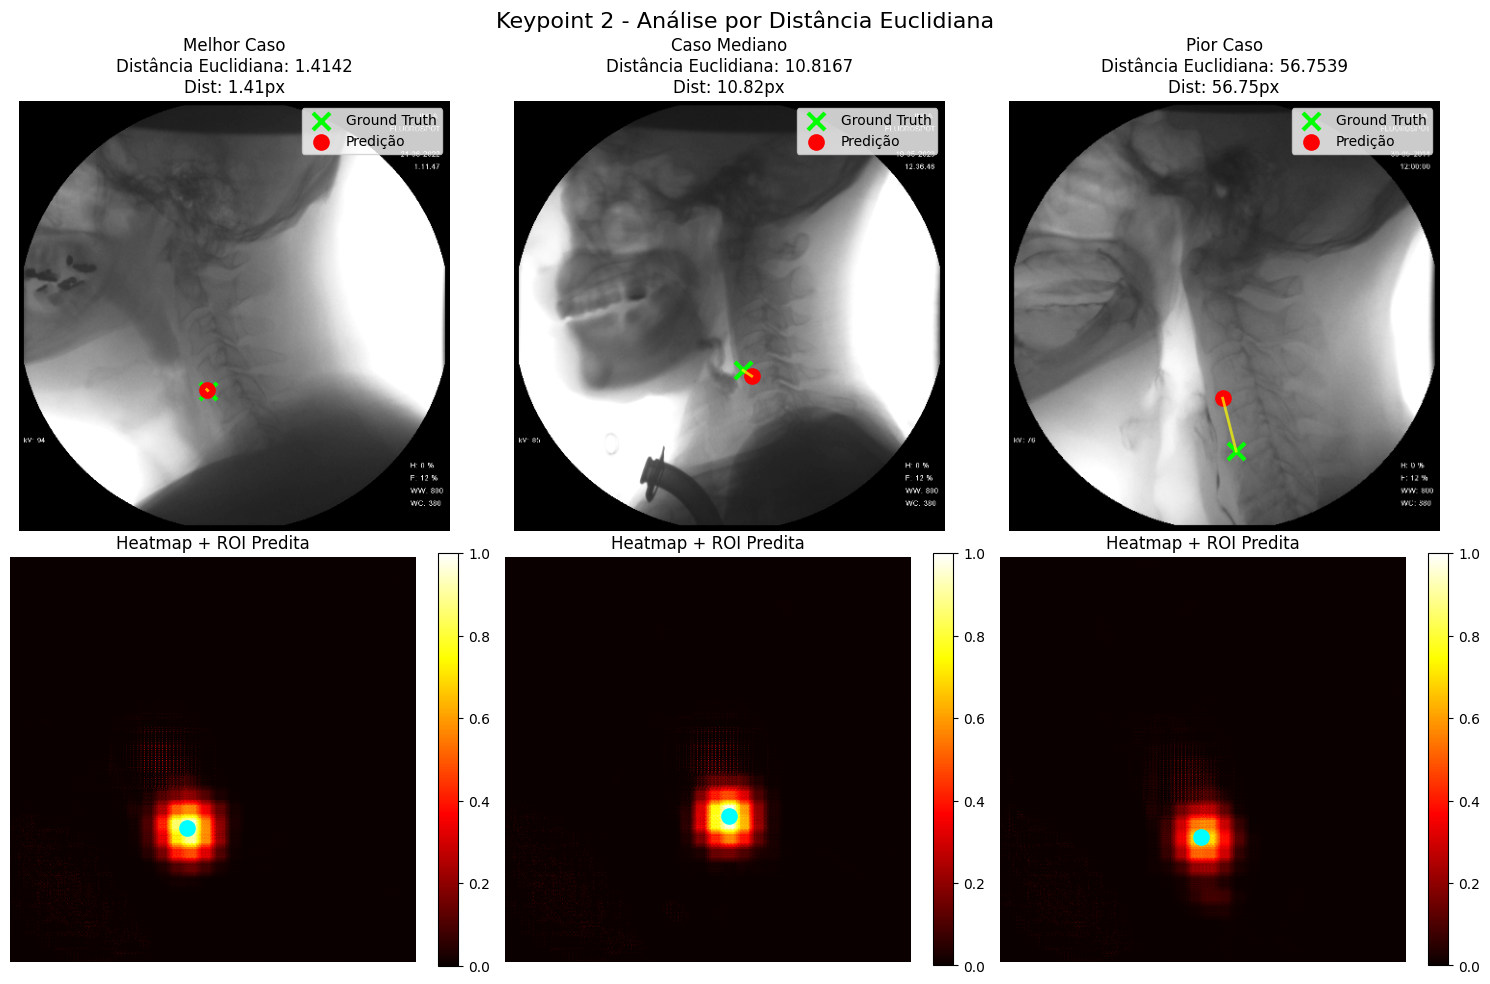


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_48W\fold1\predictions_by_loss_keypoint1.png


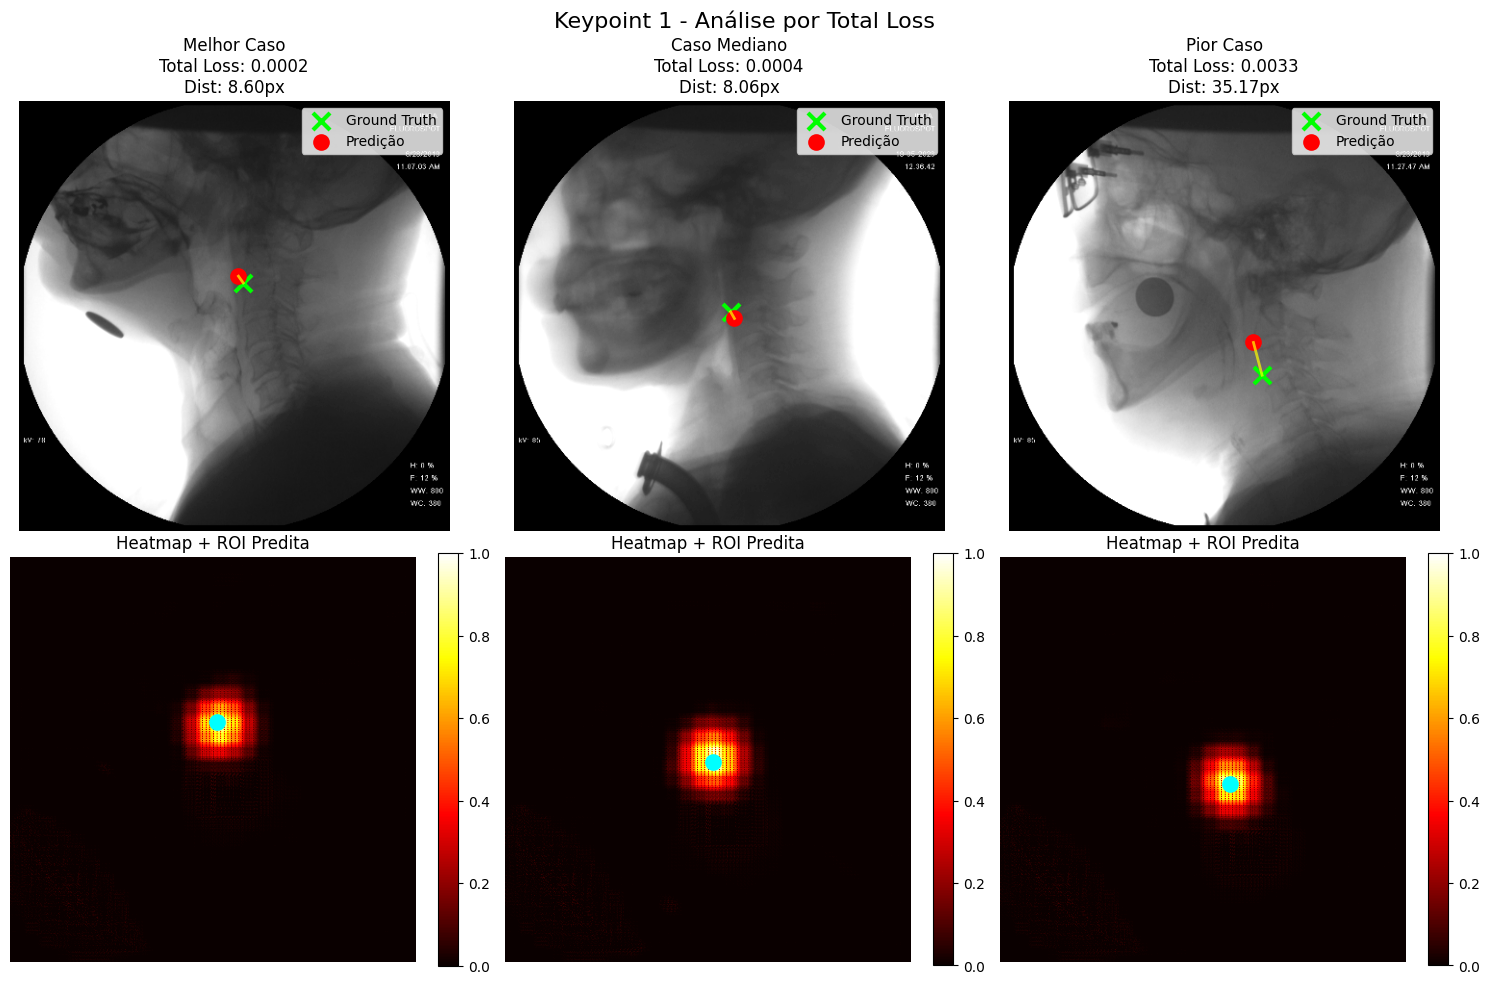


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_48W\fold1\predictions_by_loss_keypoint2.png


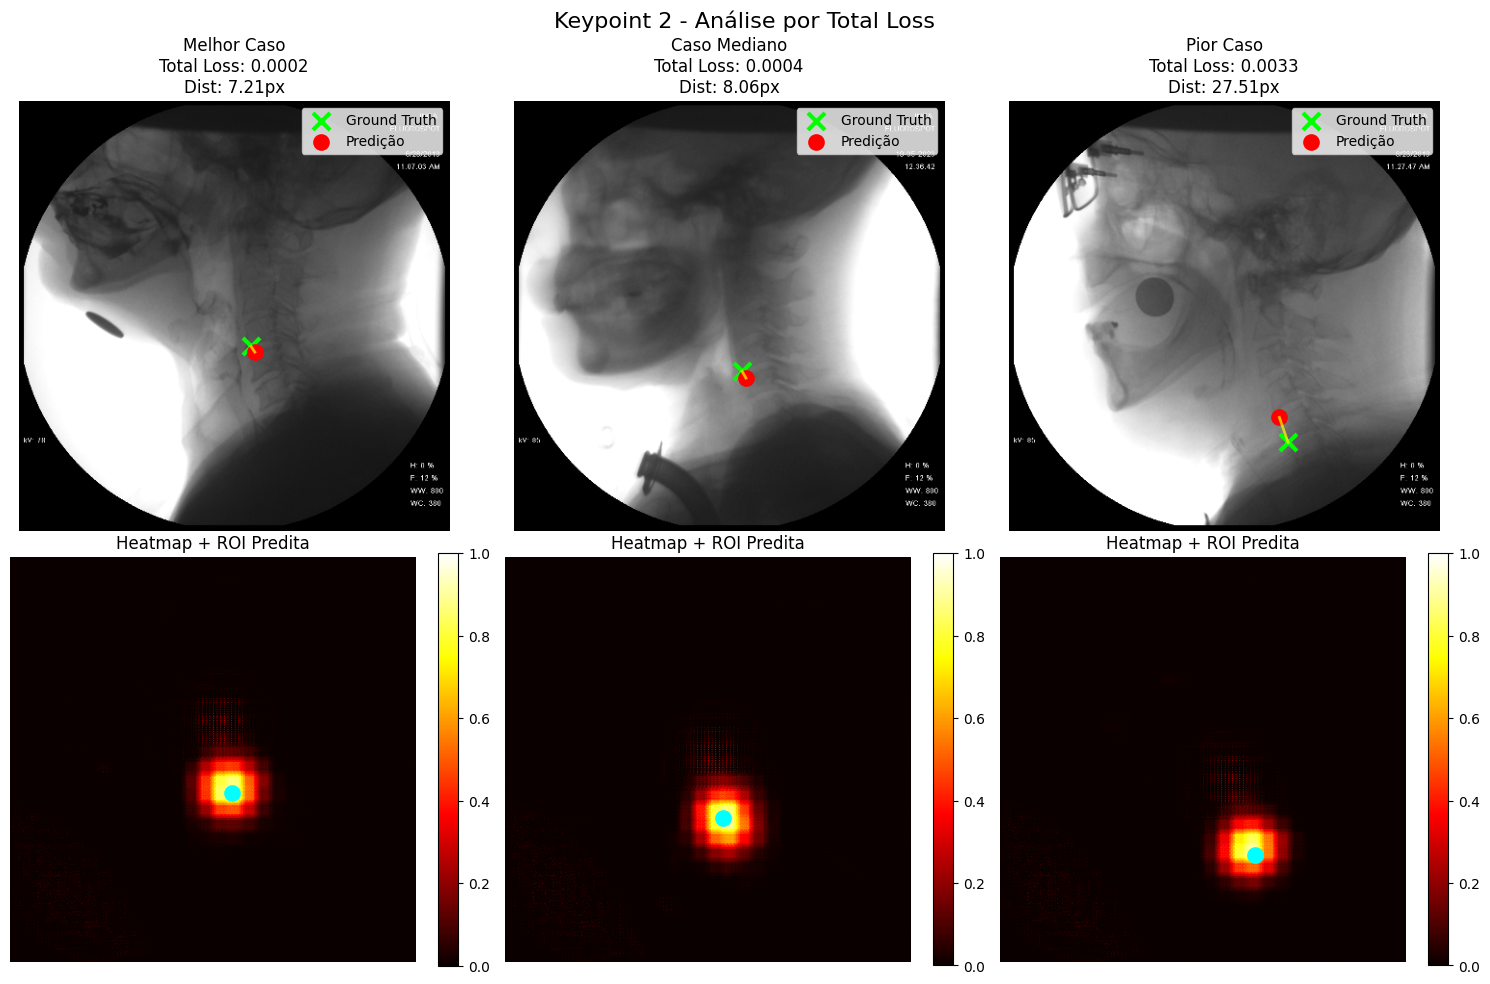

RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE

Número de amostras: 178

----------------------------------------------------------------------
LOSS TOTAL
----------------------------------------------------------------------
Média:    0.000723
Mediana:  0.000442
Std:      0.000597
Min:      0.000219
Max:      0.003275

----------------------------------------------------------------------
HEATMAP LOSS
----------------------------------------------------------------------
Média:    0.001447
Mediana:  0.000884
Std:      0.001194

----------------------------------------------------------------------
ROI LOSS
----------------------------------------------------------------------
Média:    0.000000
Mediana:  0.000000
Std:      0.000000

----------------------------------------------------------------------
KEYPOINT 1 - DISTÂNCIA EUCLIDIANA (pixels)
----------------------------------------------------------------------
Média:    9.24
Mediana:  7.14
Std:      8.18
Min:      1.00
Max:      45.2

c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\.venv\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [7]:
# TESTE

# Conjunto de Teste
test_dataset = VFSSImageDataset(
    video_frame_df = df_test,
    output_dim = config.output_dim,
    transform = config.transform_validation,      # Sempre sem augmentation para o Teste, então deve ser deterministico
    sigma_heatmap = config.sigma_heatmap,
)

root = f"data\\model_weights\\{model_name}\\"
pattern = re.compile(r"fold_([1-9])_best\.pth$")
if os.path.exists(root):
    for filename in os.listdir(root):
        match = pattern.search(filename)
        if match:
            fold_number = int(match.group(1))
            checkpoint_path = os.path.join(root, filename)
    
            # Executa avaliação completa
            results = evaluate_model_on_test(
                checkpoint_path=checkpoint_path,
                test_dataset=test_dataset,
                output_dir=f"figs\\{model_name}\\fold{fold_number}",
                config=config
            )